###Question (1): Implementation of Standard K-Means

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load the Old Faithful Dataset

In [ ]:
url = "https://people.sc.fsu.edu/~jburkardt/data/csv/faithful.csv"

data = pd.read_csv(url)

data = data.iloc[:,1:]

X = data.values
print(data.head())

    "Eruption length (mins)"  Eruption wait (mins)
0                      3.600                    79
1                      1.800                    54
2                      3.333                    74
3                      2.283                    62
4                      4.533                    85


Define Euclidean Distance

In [ ]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1-x2)**2))

Implement K-Means from Scratch

In [ ]:
def kmeans(X, K=2, max_iter=100, tol=1e-4):

  n_samples, n_features = X.shape

  centroids = X[np.random.choice(n_samples, K, replace=False)]
  objective_values = []

  for iteration in range(max_iter):
    clusters = [[] for _ in range(K)]

    for idx, point in enumerate(X):
      distances = [euclidean_distance(point, centroid) for centroid in centroids]
      cluster_index = np.argmin(distances)
      clusters[cluster_index].append(idx)

    new_centroids = np.zeros_like(centroids)

    for i in range(K):
      new_centroids[i] = np.mean(X[clusters[i]], axis=0)

    J=0
    for i in range(K):
      for idx in clusters[i]:
        J+= np.sum((X[idx] - new_centroids[i])**2)

    objective_values.append(J)

    centroid_shift = np.linalg.norm(new_centroids - centroids)
    if centroid_shift < tol:
      print(f"Converged at iteration {iteration}")
      break

    centroids = new_centroids

  return clusters, centroids, objective_values

Run K-Means

In [ ]:
clusters, centroids, objective_values = kmeans(X, K=2, max_iter=100, tol=1e-4)

print("Final Centroids:")
print(centroids)

Converged at iteration 2
Final Centroids:
[[ 2.09433    54.75      ]
 [ 4.29793023 80.28488372]]


Plot Clustered Dataset

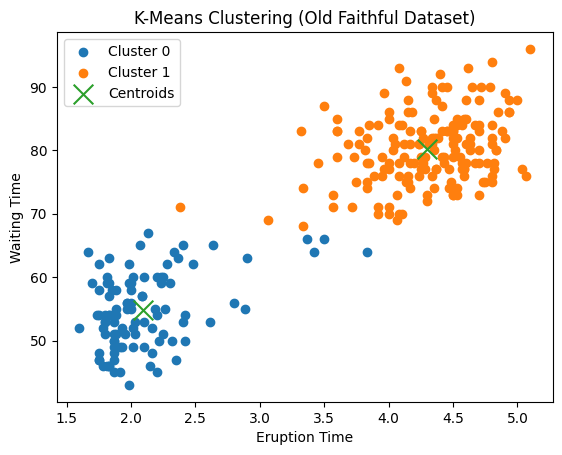

In [ ]:
plt.figure()

for i, cluster in enumerate(clusters):
    points = X[cluster]
    plt.scatter(points[:,0], points[:,1], label=f'Cluster {i}')

plt.scatter(centroids[:,0], centroids[:,1], marker='x', s=200, label='Centroids')

plt.xlabel("Eruption Time")
plt.ylabel("Waiting Time")
plt.title("K-Means Clustering (Old Faithful Dataset)")
plt.legend()

plt.show()

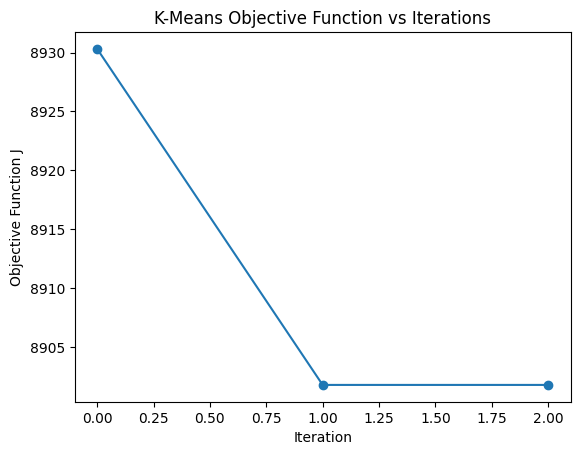

In [ ]:
plt.figure()

plt.plot(objective_values, marker='o')

plt.xlabel("Iteration")
plt.ylabel("Objective Function J")
plt.title("K-Means Objective Function vs Iterations")

plt.show()

### Question (2): Empirical Behaviour of K-Means

In [ ]:
def kmeans(X, K=2, max_iter=100, tol=1e-4):

    n_samples, n_features = X.shape

    random_indices = np.random.choice(n_samples, K, replace=False)
    centroids = X[random_indices]

    objective_values = []

    for iteration in range(max_iter):

        clusters = [[] for _ in range(K)]

        # Assign clusters
        for idx, point in enumerate(X):
            distances = [np.linalg.norm(point - centroid) for centroid in centroids]
            cluster_index = np.argmin(distances)
            clusters[cluster_index].append(idx)

        # Update centroids
        new_centroids = np.zeros_like(centroids)

        for i in range(K):
            new_centroids[i] = np.mean(X[clusters[i]], axis=0)

        # Compute objective function
        J = 0
        for i in range(K):
            for idx in clusters[i]:
                J += np.sum((X[idx] - new_centroids[i])**2)

        objective_values.append(J)

        # Check convergence
        centroid_shift = np.linalg.norm(new_centroids - centroids)

        if centroid_shift < tol:
            break

        centroids = new_centroids

    return clusters, centroids, objective_values, iteration+1

Run K-Means 30 Times

In [ ]:
runs = 30

final_objectives = []
iterations_needed = []

for i in range(runs):
    clusters, centroids, objective_values, iterations = kmeans(X, K=2)

    final_objectives.append(objective_values[-1])
    iterations_needed.append(iterations)


Compute Required Statistics

In [ ]:
min_obj = np.min(final_objectives)
max_obj = np.max(final_objectives)
mean_obj = np.mean(final_objectives)

print("Minimum Objective Value:", min_obj)
print("Maximum Objective Value:", max_obj)
print("Mean Objective Value:", mean_obj)

Minimum Objective Value: 8901.768720947213
Maximum Objective Value: 8901.768720947215
Mean Objective Value: 8901.768720947211


Iterations Required for Each Run

In [ ]:
for i, it in enumerate(iterations_needed):
    print(f"Run {i+1}: {it} iterations")

Run 1: 4 iterations
Run 2: 5 iterations
Run 3: 4 iterations
Run 4: 6 iterations
Run 5: 3 iterations
Run 6: 5 iterations
Run 7: 5 iterations
Run 8: 6 iterations
Run 9: 3 iterations
Run 10: 2 iterations
Run 11: 4 iterations
Run 12: 4 iterations
Run 13: 3 iterations
Run 14: 5 iterations
Run 15: 2 iterations
Run 16: 2 iterations
Run 17: 5 iterations
Run 18: 4 iterations
Run 19: 6 iterations
Run 20: 3 iterations
Run 21: 3 iterations
Run 22: 5 iterations
Run 23: 6 iterations
Run 24: 5 iterations
Run 25: 3 iterations
Run 26: 5 iterations
Run 27: 3 iterations
Run 28: 6 iterations
Run 29: 4 iterations
Run 30: 4 iterations


### Question (3): Gaussian Mixture Model using EM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

Load Old Faithful Dataset

In [ ]:
url = "https://people.sc.fsu.edu/~jburkardt/data/csv/faithful.csv"

data = pd.read_csv(url)

data = data.iloc[:,1:]

X = data.values
N, D = X.shape

Initialize Parameters

In [ ]:
K = 2

# Random initialization
np.random.seed(0)

mu = X[np.random.choice(N, K, replace=False)]

Sigma = [np.cov(X.T) for _ in range(K)]

pi = np.ones(K) / K

log_likelihoods = []

EM Algorithm

In [ ]:
max_iter = 100
tol = 1e-4

for iteration in range(max_iter):

    # E-step
    gamma = np.zeros((N, K))

    for k in range(K):
        rv = multivariate_normal(mu[k], Sigma[k])
        gamma[:,k] = pi[k] * rv.pdf(X)

    gamma = gamma / gamma.sum(axis=1, keepdims=True)

    # M-step
    Nk = gamma.sum(axis=0)

    for k in range(K):

        mu[k] = (gamma[:,k][:,None] * X).sum(axis=0) / Nk[k]

        diff = X - mu[k]

        Sigma[k] = (gamma[:,k][:,None] * diff).T @ diff / Nk[k]

        pi[k] = Nk[k] / N

    # Compute Log Likelihood
    ll = 0

    for i in range(N):
        s = 0
        for k in range(K):
            rv = multivariate_normal(mu[k], Sigma[k])
            s += pi[k] * rv.pdf(X[i])
        ll += np.log(s)

    log_likelihoods.append(ll)

    # Convergence check
    if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
        print("Converged at iteration", iteration)
        break

Converged at iteration 12


Plot Log-Likelihood vs Iterations

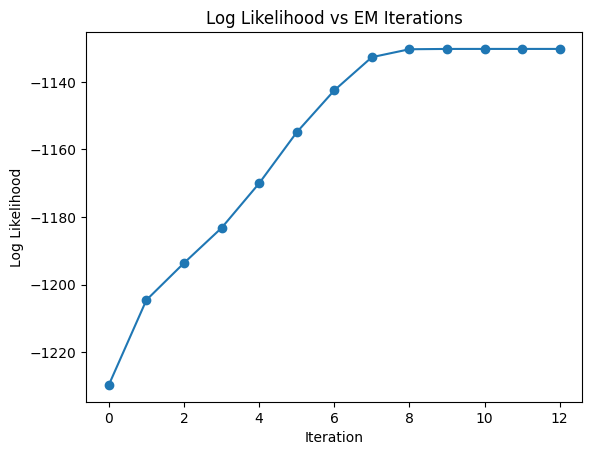

In [ ]:
plt.figure()

plt.plot(log_likelihoods, marker='o')

plt.xlabel("Iteration")
plt.ylabel("Log Likelihood")
plt.title("Log Likelihood vs EM Iterations")

plt.show()

Plot Gaussian Density Contours

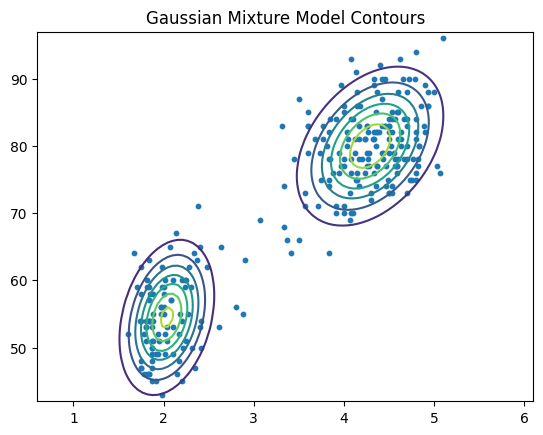

In [ ]:
x = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)

Xgrid, Ygrid = np.meshgrid(x, y)

pos = np.dstack((Xgrid, Ygrid))

plt.figure()

plt.scatter(X[:,0], X[:,1], s=10)

for k in range(K):

    rv = multivariate_normal(mu[k], Sigma[k])
    Z = rv.pdf(pos)

    plt.contour(Xgrid, Ygrid, Z)

plt.title("Gaussian Mixture Model Contours")

plt.show()

Print Final Parameters

In [ ]:
for k in range(K):

    print("\nComponent", k+1)

    print("Mean (mu):")
    print(mu[k])

    print("Covariance (Sigma):")
    print(Sigma[k])

    print("Mixing coefficient (pi):")
    print(pi[k])


Component 1
Mean (mu):
[ 4.28967178 79.96823376]
Covariance (Sigma):
[[ 0.16995599  0.94045101]
 [ 0.94045101 36.04442928]]
Mixing coefficient (pi):
0.6441225891758489

Component 2
Mean (mu):
[ 2.03639954 54.47862789]
Covariance (Sigma):
[[ 0.06917647  0.43525949]
 [ 0.43525949 33.69790893]]
Mixing coefficient (pi):
0.3558774108241513


###Question (4): Initialization for EM Algorithm

###

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

url = "https://people.sc.fsu.edu/~jburkardt/data/csv/faithful.csv"

data = pd.read_csv(url)

X = data.iloc[:,1:].values
N, D = X.shape

In [3]:
def run_em(X, mu_init, max_iter=50, tol=1e-4):

    N, D = X.shape
    K = len(mu_init)

    mu = mu_init.copy()

    Sigma = [np.cov(X.T) + np.eye(D)*1e-6 for _ in range(K)]

    pi = np.ones(K)/K

    prev_ll = None

    for iteration in range(max_iter):

        #E STEP
        gamma = np.zeros((N,K))

        for k in range(K):
            rv = multivariate_normal(mu[k], Sigma[k], allow_singular=True)
            gamma[:,k] = pi[k] * rv.pdf(X)

        gamma = gamma / gamma.sum(axis=1, keepdims=True)

        #M STEP
        Nk = gamma.sum(axis=0)

        for k in range(K):

            mu[k] = (gamma[:,k][:,None] * X).sum(axis=0) / Nk[k]

            diff = X - mu[k]

            Sigma[k] = (gamma[:,k][:,None] * diff).T @ diff / Nk[k]

            Sigma[k] += np.eye(D)*1e-6

            pi[k] = Nk[k] / N

        pi = pi / pi.sum()

        #Log Likelihood
        ll = 0

        for k in range(K):
            rv = multivariate_normal(mu[k], Sigma[k], allow_singular=True)
            ll += np.sum(np.log(pi[k]*rv.pdf(X)+1e-12))

        if prev_ll is not None and abs(ll - prev_ll) < tol:
            break

        prev_ll = ll

    return ll, iteration+1

Random Initialization Runs

In [4]:
def kmeans_simple(X, K=2, max_iter=100):

    N, D = X.shape

    centroids = X[np.random.choice(N,K,replace=False)]

    for _ in range(max_iter):

        distances = np.linalg.norm(X[:,None] - centroids, axis=2)

        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([X[labels==k].mean(axis=0) for k in range(K)])

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return centroids

In [5]:
runs = 20

random_ll = []
random_iters = []

for i in range(runs):

    mu_init = X[np.random.choice(N,2,replace=False)]

    ll, it = run_em(X, mu_init)

    random_ll.append(ll)
    random_iters.append(it)

K-Means Initialization Runs

In [6]:
kmeans_ll = []
kmeans_iters = []

for i in range(runs):

    mu_init = kmeans_simple(X,2)

    ll, it = run_em(X, mu_init)

    kmeans_ll.append(ll)
    kmeans_iters.append(it)

Create Comparison Table

In [7]:
results = pd.DataFrame({
    "Run": range(1,21),
    "Random_LL": random_ll,
    "Random_Iter": random_iters,
    "KMeans_LL": kmeans_ll,
    "KMeans_Iter": kmeans_iters
})

results

,Run,Random_LL,Random_Iter,KMeans_LL,KMeans_Iter
0,1,-3845.582058,50,-7927.008075,16
1,2,-7927.008066,15,-7927.008075,16
2,3,-7927.008075,32,-7927.008075,16
3,4,-7927.008062,20,-7927.008075,16
4,5,-7927.008063,20,-7927.008075,16
5,6,-7927.008068,19,-7927.008075,16
6,7,-7927.008081,16,-7927.008075,16
7,8,-7927.008082,16,-7927.008075,16
8,9,-7927.008065,45,-7927.008075,16
9,10,-7927.008064,30,-7927.008075,16


### Question (5): Clustering of High-Dimensional Image Data

PART 1 — K-Means on MNIST (K = 10)

In [8]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

mnist = fetch_openml('mnist_784')

X = mnist.data.values
y = mnist.target.astype(int)

# Normalize pixels
X = X / 255.0

In [9]:
X_mnist = X[:10000]

Visualize Cluster Centroids as Images

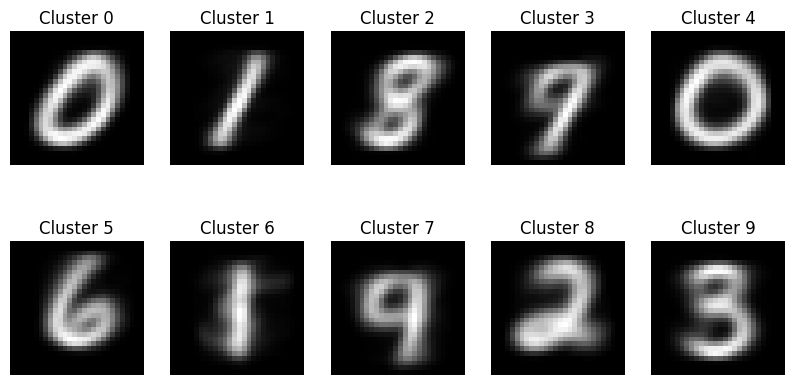

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=0)

kmeans.fit(X_mnist)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    img = centroids[i].reshape(28,28)

    plt.imshow(img, cmap='gray')

    plt.title("Cluster "+str(i))

    plt.axis('off')

plt.show()


Number of Samples per Cluster

In [12]:
for i in range(10):

    count = np.sum(labels == i)

    print("Cluster", i, "samples:", count)

Cluster 0 samples: 529
Cluster 1 samples: 754
Cluster 2 samples: 1053
Cluster 3 samples: 1486
Cluster 4 samples: 468
Cluster 5 samples: 935
Cluster 6 samples: 1476
Cluster 7 samples: 1412
Cluster 8 samples: 736
Cluster 9 samples: 1151


PART 2 — GMM (EM) on Face Dataset

In [19]:
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt

digits = load_digits()

X_faces = digits.data
y_faces = digits.target

In [16]:
X_faces = X_faces / 16.0

Run EM Algorithm

In [23]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
        n_components=K,
        covariance_type='full',
        random_state=0,
        max_iter=100
      )

gmm.fit(X_faces)

labels = gmm.predict(X_faces)

Plot Log-Likelihood Curve

/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/usr/local/lib/python3.1

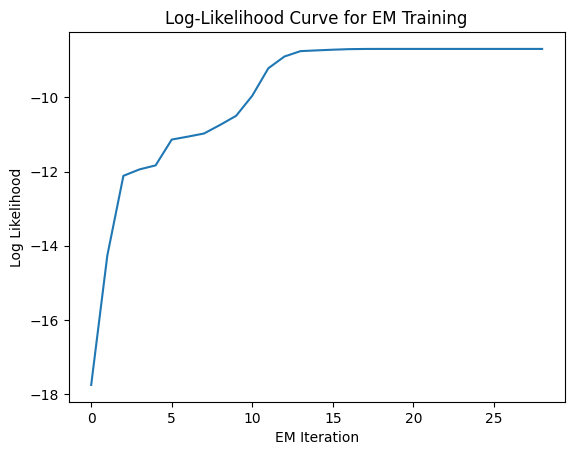

In [24]:
log_likelihoods = []

for i in range(1,30):

    gmm_iter = GaussianMixture(
        n_components=K,
        covariance_type='full',
        max_iter=i,
        random_state=0
    )

    gmm_iter.fit(X_faces)

    log_likelihoods.append(gmm_iter.lower_bound_)

plt.plot(log_likelihoods)

plt.xlabel("EM Iteration")
plt.ylabel("Log Likelihood")

plt.title("Log-Likelihood Curve for EM Training")

plt.show()

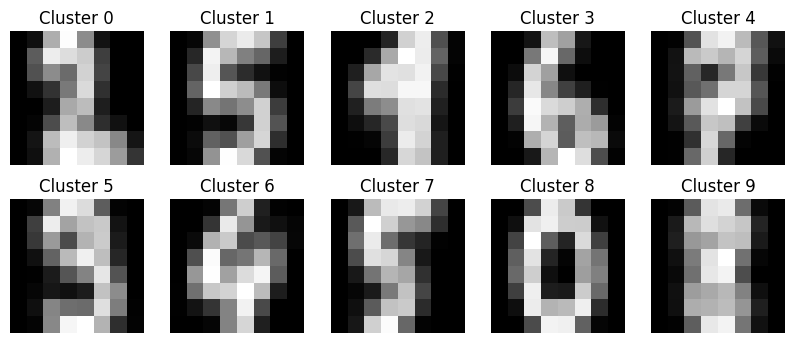

In [25]:
means = gmm.means_

plt.figure(figsize=(10,4))

for i in range(K):

    plt.subplot(2,5,i+1)

    img = means[i].reshape(8,8)

    plt.imshow(img, cmap='gray')

    plt.title("Cluster " + str(i))

    plt.axis('off')

plt.show()

Number of Samples per Cluster

In [26]:
for i in range(K):

    count = np.sum(labels == i)

    print("Cluster", i, "samples:", count)

Cluster 0 samples: 184
Cluster 1 samples: 87
Cluster 2 samples: 95
Cluster 3 samples: 180
Cluster 4 samples: 193
Cluster 5 samples: 266
Cluster 6 samples: 167
Cluster 7 samples: 117
Cluster 8 samples: 179
Cluster 9 samples: 329
